In [ ]:
# ==============================
# STEP 1: Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ==============================
# STEP 2: Load Dataset
# ==============================

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ==============================
# STEP 3: Data Cleaning
# ==============================

# Drop customerID (not useful for prediction)
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Handle missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print("Missing values:\n", df.isnull().sum())

Missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# ==============================
# STEP 4: Encode Target Variable
# ==============================

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
# ==============================
# STEP 5: Encode Categorical Columns
# ==============================

categorical_cols = df.select_dtypes(include=["object"]).columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("New Dataset Shape:", df_encoded.shape)
df_encoded.head()

New Dataset Shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
# ==============================
# STEP 6: Split Features and Target
# ==============================

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


In [ ]:
# ==============================
# STEP 7: Feature Scaling
# ==============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ==============================
# STEP 8: Logistic Regression
# ==============================

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7388218594748048



Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



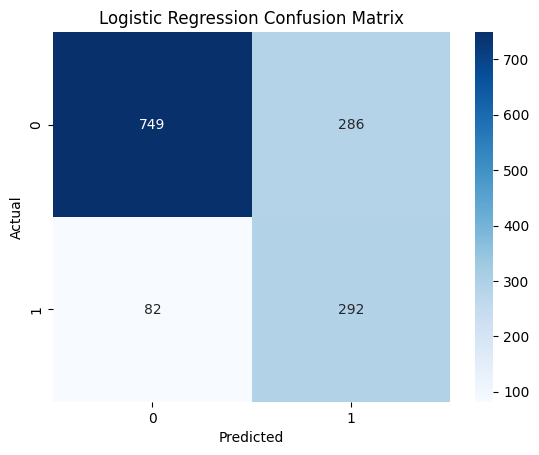

In [ ]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ==============================
# STEP 10: Random Forest
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7636621717530163



Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



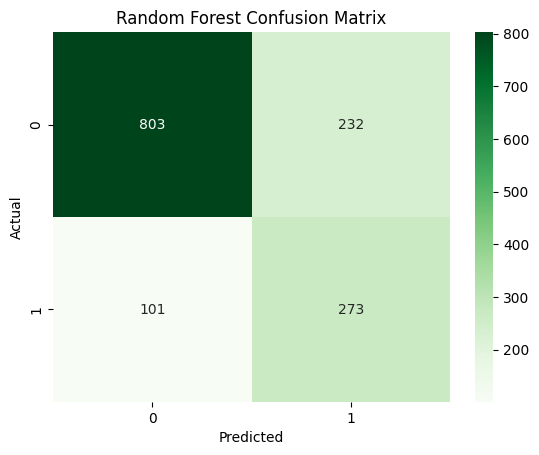

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

STEP 12 — Comparing Models

In [ ]:
log_acc = accuracy_score(y_test, y_pred_log)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression Accuracy:", log_acc)
print("Random Forest Accuracy:", rf_acc)

if rf_acc > log_acc:
    print("Random Forest performs better.")
else:
    print("Logistic Regression performs better.")

Logistic Regression Accuracy: 0.7388218594748048
Random Forest Accuracy: 0.7636621717530163
Random Forest performs better.


In [ ]:
# ==============================
# STEP 13: Save Best Model
# ==============================

best_model = rf_model if rf_acc > log_acc else log_model

joblib.dump(best_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_log))

print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Random Forest Report:

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.73      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



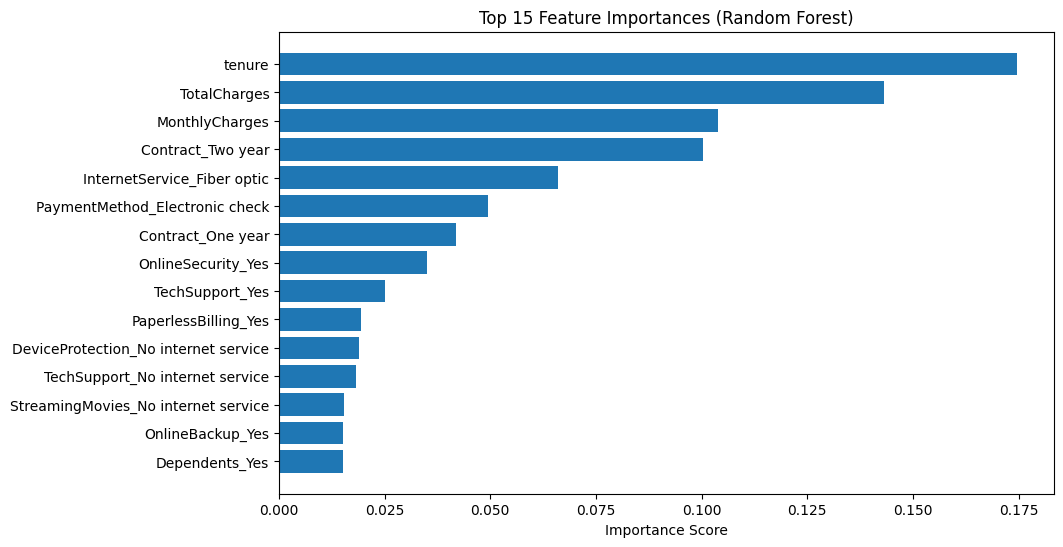

In [ ]:
# ==============================
# FEATURE IMPORTANCE (Random Forest)
# ==============================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_

# Get feature names
feature_names = X_train.columns

# Create DataFrame
feat_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feat_importance = feat_importance.sort_values(by="Importance", ascending=False)

# Plot top 15 features
plt.figure(figsize=(10,6))
plt.barh(feat_importance["Feature"][:15][::-1],
         feat_importance["Importance"][:15][::-1])
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

SHAP EXPLAINABILITY (REAL XAI)

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
# Convert all columns to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(X_train.dtypes.unique())

[dtype('float64')]


100%|===================| 2812/2818 [03:57<00:00]       

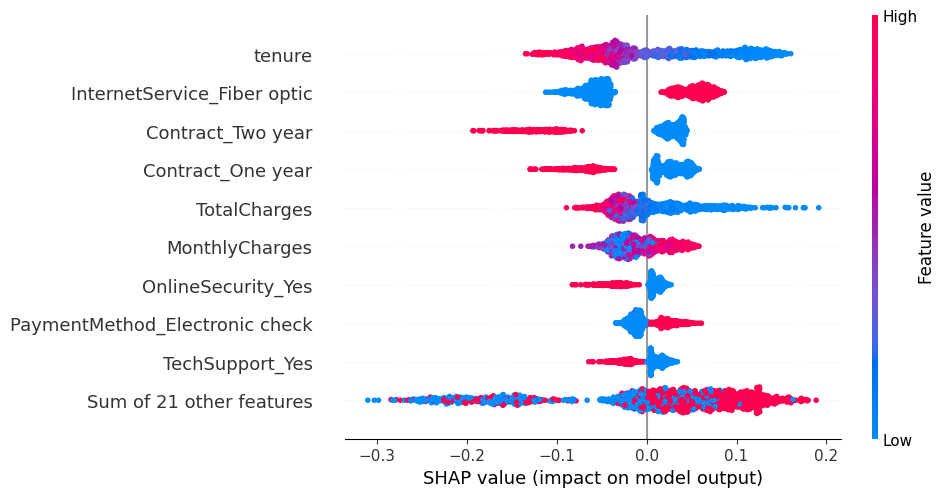

In [ ]:
# ==============================
# SHAP EXPLAINABILITY
# ==============================


# Modern SHAP explainer
explainer = shap.Explainer(rf_model, X_train)

# Disable strict additivity check
shap_values = explainer(X_test, check_additivity=False)

# For binary classification, select churn class (class index 1)
shap.plots.beeswarm(shap_values[:, :, 1])

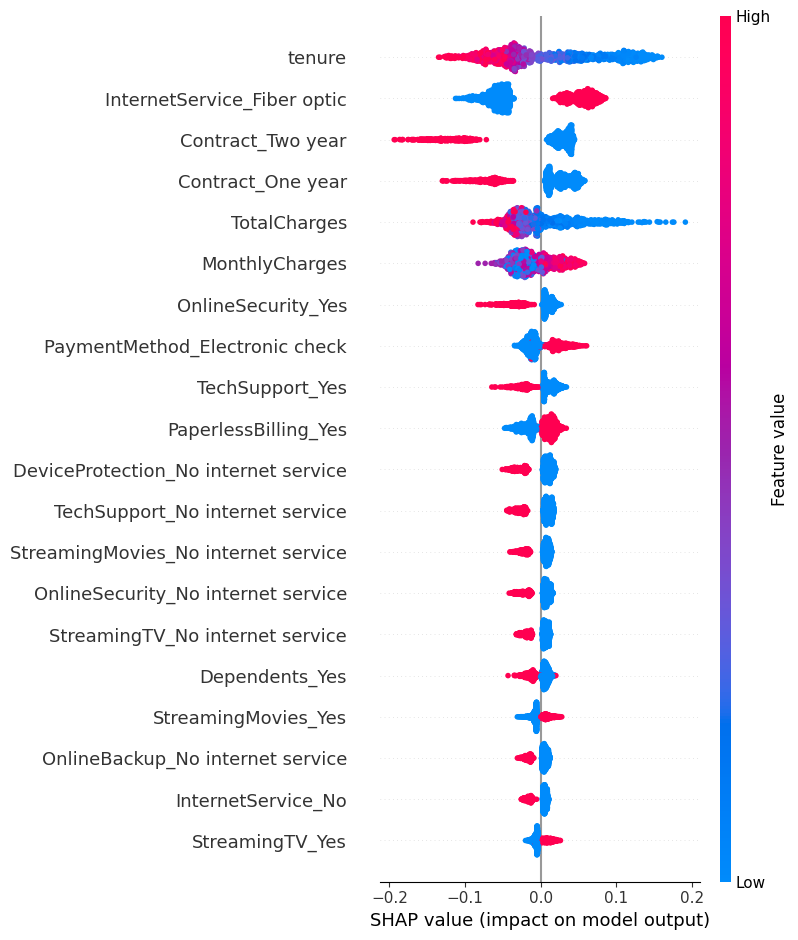

In [ ]:
# Summary plot for churn class (1)
shap.summary_plot(shap_values[:, :, 1], X_test)